# Depth bands of PSBD-TM

PSBD-TM masks tokens at the attention input of all 12 blocks. A band restricts the same placement to blocks 1 to 4, 5 to 8 or 9 to 12, which asks whether the detection signal comes from 1 depth of the network or needs the perturbation at every depth. This notebook follows `scripts/paper/tab_depth_bands.py`, which reads each band at the matched rate rule rather than the adaptive one, and pairs each band with the all-blocks placement on the same models. It reads cached JSON only and runs in a few seconds.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cli.compare_detectors import psbd_rate
from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    RECOMMENDED_PLACEMENT,
)
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    OKABE_ITO,
    bootstrap_ci,
    clearing_cells,
    load_coverage,
    load_psbd_metrics,
)
from scripts.paper._style import TEXT_WIDTH
from scripts.paper.tab_depth_bands import (
    INPUT_SIDE_1_4,
    INPUT_SIDE_5_8,
    INPUT_SIDE_9_12,
    INPUT_SIDE_ALL,
    measure_placement,
)

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

## Why the matched rule

The adaptive rule picks the smallest rate whose clean-validation predictions shift at the adaptive target. A band perturbs 4 of the 12 blocks, so on many models no rate on the ladder shifts the predictions that often, and the adaptive rule returns nothing. The matched rule reads every placement at a lower shift target, which a band reaches on every model it was swept on, so the comparison rests on the whole swept panel.

In [4]:
assert INPUT_SIDE_ALL == RECOMMENDED_PLACEMENT
BANDS = {
    "all blocks": INPUT_SIDE_ALL,
    "blocks 1 to 4": INPUT_SIDE_1_4,
    "blocks 5 to 8": INPUT_SIDE_5_8,
    "blocks 9 to 12": INPUT_SIDE_9_12,
}

cells = clearing_cells(load_coverage("results"))
reports = {
    cell["folder_name"]: load_psbd_metrics("results", cell["folder_name"]) or {}
    for cell in cells
}

reach_rows = []
for band, placement in BANDS.items():
    blocks = [
        report.get("placements", {}).get(placement) for report in reports.values()
    ]
    swept = [block for block in blocks if block is not None]
    reach_rows.append(
        {
            "band": band,
            "swept": len(swept),
            f"adaptive {ADAPTIVE_SHIFT_TARGET} reached": sum(
                psbd_rate(block, "adaptive") is not None for block in swept
            ),
            f"matched {PLACEMENT_MATCH_TARGET} reached": sum(
                psbd_rate(block, "matched") is not None for block in swept
            ),
        }
    )
print(
    f"{len(cells)} clearing models, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile"
)
pd.DataFrame(reach_rows).set_index("band")

71 clearing models, threshold at the 25% clean-validation quantile


,swept,adaptive 0.8 reached,matched 0.6 reached
band,,,
all blocks,71,69,71
blocks 1 to 4,65,12,65
blocks 5 to 8,71,44,71
blocks 9 to 12,71,31,71


## Paired band readings

The figure uses the models carrying all 4 readings at the matched rule, so every bar averages the same models. The paired gap of each band against all blocks carries a bootstrap interval over those models.

In [5]:
band_rows = []
for folder, report in reports.items():
    row = {"folder": folder}
    for band, placement in BANDS.items():
        measured = measure_placement(report, placement)
        row[band] = None if measured is None else measured["auroc"]
    band_rows.append(row)
per_model = pd.DataFrame(band_rows).set_index("folder").dropna()  # (models, bands)
assert list(per_model.columns) == list(BANDS)

gap_rows = []
for band in list(BANDS)[1:]:
    deltas = (per_model[band] - per_model["all blocks"]).tolist()
    low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gap_rows.append(
        {
            "band": band,
            "mean AUROC": per_model[band].mean(),
            "gap to all blocks": np.mean(deltas),
            "low": low,
            "high": high,
        }
    )
gaps = pd.DataFrame(gap_rows).set_index("band")

print(
    f"{len(per_model)} models carry every band at the matched {PLACEMENT_MATCH_TARGET} rule"
)
print(f"all blocks mean AUROC {per_model['all blocks'].mean():.3f}")
print("standard deviation across models:", per_model.std().round(3).to_dict())
gaps.round(3)

65 models carry every band at the matched 0.6 rule
all blocks mean AUROC 0.926
standard deviation across models: {'all blocks': 0.098, 'blocks 1 to 4': 0.171, 'blocks 5 to 8': 0.165, 'blocks 9 to 12': 0.184}


,mean AUROC,gap to all blocks,low,high
band,,,,
blocks 1 to 4,0.822,-0.103,-0.139,-0.070
blocks 5 to 8,0.863,-0.063,-0.100,-0.031
blocks 9 to 12,0.864,-0.062,-0.108,-0.021


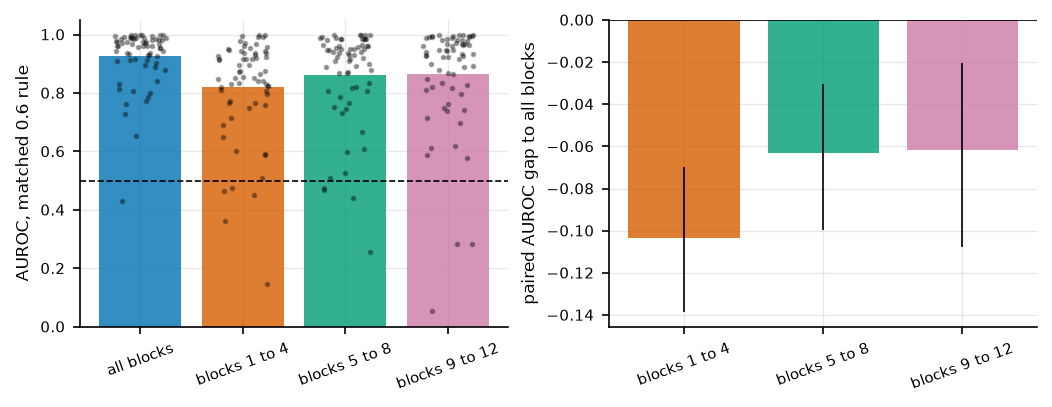

In [6]:
figure, (mean_axis, gap_axis) = plt.subplots(
    1, 2, figsize=(TEXT_WIDTH, 2.6), layout="constrained"
)
band_positions = np.arange(len(BANDS))  # (bands,)
band_colors = [OKABE_ITO[index] for index in range(len(BANDS))]
jitter = np.random.default_rng(0)

mean_axis.bar(band_positions, per_model.mean(), color=band_colors, alpha=0.8)
for position, band in zip(band_positions, BANDS):
    offsets = jitter.uniform(-0.25, 0.25, size=len(per_model))  # (models,)
    mean_axis.scatter(
        position + offsets, per_model[band], color="black", s=3, alpha=0.3
    )
mean_axis.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
mean_axis.set_xticks(band_positions, labels=list(BANDS), rotation=20)
mean_axis.set_ylabel(f"AUROC, matched {PLACEMENT_MATCH_TARGET} rule")

gap_positions = band_positions[1:]  # (bands minus 1,)
gap_errors = np.vstack(
    [gaps["gap to all blocks"] - gaps["low"], gaps["high"] - gaps["gap to all blocks"]]
)  # (2, bands minus 1)
gap_axis.bar(gap_positions, gaps["gap to all blocks"], color=band_colors[1:], alpha=0.8)
gap_axis.errorbar(
    gap_positions,
    gaps["gap to all blocks"],
    yerr=gap_errors,
    fmt="none",
    ecolor="black",
    linewidth=0.8,
)
gap_axis.axhline(0.0, color="black", linewidth=0.8)
gap_axis.set_xticks(gap_positions, labels=list(gaps.index), rotation=20)
gap_axis.set_ylabel("paired AUROC gap to all blocks")
plt.show()

## Reading the bands

Every band loses to all blocks, and every gap interval sits below 0, so no band of 4 blocks carries the signal on its own. The 2 later bands lose about equally and the early band loses the most, which fits the mechanism the paper describes, where attention moves a trigger's evidence toward the class token in the middle and late blocks and a mask has to be in place at whichever depth that routing happens. The spread across models is wider in every band than in all blocks, so a band that works on 1 model fails on another, and acting in every block removes that dependence on the depth of the routing.